# Airline Merger Damages Estimator — Preprocessing

**STAT 418 — Data/ML/AI Applications, UCLA**

Loads all 32 quarters of DOT DB1B Market data, applies cleaning filters, engineers all features required for causal modeling, merges FRED macroeconomic controls, runs validation checks, and saves the analysis-ready panel dataset.

**Output:** `data/processed/panel.parquet` — the single file that `03_modeling.ipynb` will load.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

# Paths (relative to notebooks/ directory)
DATA_DIR   = Path('../data/raw/db1b')
FRED_DIR   = Path('../data/raw/fred')
PROC_DIR   = Path('../data/processed')
MODELS_DIR = Path('../models/artifacts')
PROC_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Columns to load from each parquet file — only what modeling needs
LOAD_COLS = [
    'Year', 'Quarter', 'Origin', 'Dest', 'OpCarrier',
    'MktFare', 'Passengers', 'MktDistance', 'MktCoupons',
    'BulkFare', 'OriginState', 'DestState', 'MktGeoType'
]

print('Setup complete.')
print(f'  DB1B files : {DATA_DIR}')
print(f'  FRED files : {FRED_DIR}')
print(f'  Output     : {PROC_DIR}')

Setup complete.
  DB1B files : ..\data\raw\db1b
  FRED files : ..\data\raw\fred
  Output     : ..\data\processed


---
## Section 1 — Treatment Assignment

Scan all **16 pre-merger quarters (2010 Q1 – 2013 Q4)** to determine which routes both AA and US Airways served. Treatment is **route-level and time-invariant**.

- **Treated:** route in `aa_routes AND us_routes`
- **Control:** route in `aa_routes XOR us_routes` (only one carrier)
- Routes where neither carrier operated are excluded from the study entirely.

In [2]:
# Scan all pre-merger quarters, loading only carrier + filter columns
aa_routes = set()
us_routes = set()

for year in range(2010, 2014):
    for q in range(1, 5):
        fp = DATA_DIR / f'db1b_market_{year}_Q{q}.parquet'
        df = pd.read_parquet(fp, columns=['Origin', 'Dest', 'OpCarrier',
                                           'MktCoupons', 'BulkFare', 'MktGeoType'])
        # Base filters
        df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
        df = df[df['MktGeoType'].isin([1, 2])]
        df = df[df['MktCoupons'] == 1]
        df = df[df['BulkFare'] == 0]
        df['route'] = df['Origin'] + '-' + df['Dest']
        aa_routes |= set(df.loc[df['OpCarrier'] == 'AA', 'route'])
        us_routes |= set(df.loc[df['OpCarrier'] == 'US', 'route'])
        del df
        print(f'  Scanned {year} Q{q}', end='\r')

treated_routes   = aa_routes & us_routes
control_routes   = (aa_routes | us_routes) - treated_routes
all_study_routes = treated_routes | control_routes

print(f'\nTreated routes (AA + US overlap)  : {len(treated_routes):,}')
print(f'Control routes (one carrier only)  : {len(control_routes):,}')
print(f'Total study routes                 : {len(all_study_routes):,}')
print(f'Treatment share                    : {len(treated_routes)/len(all_study_routes):.1%}')

  Scanned 2013 Q4
Treated routes (AA + US overlap)  : 1,223
Control routes (one carrier only)  : 3,723
Total study routes                 : 4,946
Treatment share                    : 24.7%


In [3]:
# Save treatment assignment for reference and API use
treatment_df = pd.DataFrame({
    'route':   sorted(all_study_routes),
    'treated': [1 if r in treated_routes else 0 for r in sorted(all_study_routes)]
})
treatment_df.to_parquet(PROC_DIR / 'treatment_assignment.parquet', index=False)

print(f'Saved treatment_assignment.parquet  ({len(treatment_df):,} routes)')
print(treatment_df['treated'].value_counts().rename({1: 'Treated', 0: 'Control'}).to_string())

Saved treatment_assignment.parquet  (4,946 routes)
treated
Control    3723
Treated    1223


---
## Section 2 — Data Cleaning Filters

Applied consistently to every quarter before building the panel.

| Filter | Rationale |
|---|---|
| `MktGeoType in [1, 2]` | Domestic itineraries only |
| `MktCoupons == 1` | Nonstop routes only — cleaner identification |
| `BulkFare == 0` | Remove bulk/group fares (not representative of retail prices) |
| `MktFare > 20` and `< 2000` | Remove outliers and data errors |
| `Passengers > 0` | Remove zero-passenger records |

In [4]:
def apply_base_filters(df: pd.DataFrame) -> pd.DataFrame:
    """Apply all standard cleaning filters to a raw DB1B Market DataFrame."""
    # Drop BTS trailing artifact column
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
    # Domestic itineraries only
    if 'MktGeoType' in df.columns:
        df = df[df['MktGeoType'].isin([1, 2])]
    # Nonstop routes only (cleaner causal identification)
    df = df[df['MktCoupons'] == 1]
    # Remove bulk/group fares
    df = df[df['BulkFare'] == 0]
    # Fare outlier removal
    df = df[(df['MktFare'] > 20) & (df['MktFare'] < 2000)]
    # Positive passengers
    df = df[df['Passengers'] > 0]
    return df

print('apply_base_filters defined.')

apply_base_filters defined.


---
## Section 3 — Feature Engineering

All features are computed per-quarter on the filtered ticket-level data **before** aggregating to route-quarter level.

| Feature | Description |
|---|---|
| `route` | `Origin + '-' + Dest` |
| `treated` | 1 if both AA+US flew route pre-merger, else 0 |
| `post` | 1 if quarter is Q4 2013 or later |
| `treated_post` | DiD interaction: `treated × post` |
| `quarter_idx` | Integer time index: 0 = 2010 Q1, 31 = 2017 Q4 |
| `event_time` | Quarters relative to merger: 0 = Q4 2013, negative = pre |
| `log_fare` | `log(MktFare)` — log-linear outcome |
| `passengers_scaled` | `Passengers × 10` — population-level estimate |

In [5]:
def engineer_features(df: pd.DataFrame, treated_routes: set) -> pd.DataFrame:
    """Add all modeling features to a filtered ticket-level DataFrame."""
    df = df.copy()
    df['route']             = df['Origin'] + '-' + df['Dest']
    df['treated']           = df['route'].isin(treated_routes).astype(int)
    df['post']              = (
        (df['Year'] > 2013) |
        ((df['Year'] == 2013) & (df['Quarter'] == 4))
    ).astype(int)
    df['treated_post']      = df['treated'] * df['post']
    df['quarter_idx']       = (df['Year'] - 2010) * 4 + (df['Quarter'] - 1)
    df['event_time']        = df['quarter_idx'] - 15   # 0 = merger quarter (2013 Q4)
    df['log_fare']          = np.log(df['MktFare'])
    df['passengers_scaled'] = df['Passengers'] * 10    # DB1B is 10% sample
    return df

print('engineer_features defined.')

engineer_features defined.


---
## Sections 4 & 5 — Route-Quarter Aggregation and HHI Computation

**Memory strategy:** Process one quarter at a time. Each iteration:
1. Load only the 13 needed columns
2. Apply cleaning filters
3. Restrict to study routes (AA/US routes only)
4. Compute HHI from raw ticket-level carrier shares (all carriers on route)
5. Engineer features
6. Aggregate tickets to route-quarter level
7. Merge HHI onto aggregated DataFrame
8. Append chunk — then `del` the large intermediate DataFrames

The chunk that gets appended is already at route-quarter level (~5,000 rows), so the final `pd.concat` is fast and memory-safe.

In [6]:
def compute_hhi(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Herfindahl-Hirschman Index per route-quarter.
    Uses raw (unscaled) Passengers. HHI in [0, 1]: 0 = competitive, 1 = monopoly.
    """
    carrier_shares = (
        df.groupby(['Year', 'Quarter', 'route', 'OpCarrier'])['Passengers']
        .sum()
        .reset_index()
    )
    route_totals = (
        carrier_shares.groupby(['Year', 'Quarter', 'route'])['Passengers']
        .sum()
        .rename('Passengers_total')
        .reset_index()
    )
    carrier_shares = carrier_shares.merge(route_totals, on=['Year', 'Quarter', 'route'])
    carrier_shares['share'] = carrier_shares['Passengers'] / carrier_shares['Passengers_total']
    hhi = (
        carrier_shares.groupby(['Year', 'Quarter', 'route'])['share']
        .apply(lambda s: (s ** 2).sum())
        .rename('hhi')
        .reset_index()
    )
    return hhi

print('compute_hhi defined.')

compute_hhi defined.


In [7]:
# Main processing loop — all 32 quarters
# Each chunk is aggregated to route-quarter level before appending
chunks = []

for year in range(2010, 2018):
    for q in range(1, 5):
        fp = DATA_DIR / f'db1b_market_{year}_Q{q}.parquet'

        # 1. Load minimal columns
        df = pd.read_parquet(fp, columns=LOAD_COLS)

        # 2. Apply base cleaning filters
        df = apply_base_filters(df)

        # 3. Restrict to study routes (AA/US routes only)
        df['route'] = df['Origin'] + '-' + df['Dest']
        df = df[df['route'].isin(all_study_routes)].copy()

        if len(df) == 0:
            print(f'  WARNING: no study-route rows in {year} Q{q}')
            continue

        # 4. HHI — computed before feature engineering (uses raw Passengers)
        hhi_chunk = compute_hhi(df)

        # 5. Feature engineering
        df = engineer_features(df, treated_routes)

        # 6. Route-quarter aggregation
        route_quarter = (
            df.groupby([
                'Year', 'Quarter', 'route', 'treated', 'post',
                'treated_post', 'quarter_idx', 'event_time',
                'Origin', 'Dest', 'OriginState', 'DestState'
            ]).agg(
                avg_fare         = ('MktFare',          'mean'),
                median_fare      = ('MktFare',          'median'),
                log_avg_fare     = ('log_fare',         'mean'),
                total_passengers = ('passengers_scaled', 'sum'),
                n_tickets        = ('MktFare',           'count'),
                avg_distance     = ('MktDistance',       'mean'),
                n_carriers       = ('OpCarrier',         'nunique'),
            )
            .reset_index()
        )

        # 7. Merge HHI
        route_quarter = route_quarter.merge(hhi_chunk, on=['Year', 'Quarter', 'route'], how='left')

        chunks.append(route_quarter)

        # 8. Free memory immediately
        del df, hhi_chunk, route_quarter

        print(f'  Processed {year} Q{q}', end='\r')

print(f'\nProcessed {len(chunks)} quarter-chunks.')

  Processed 2017 Q4
Processed 32 quarter-chunks.


In [8]:
# Concatenate all quarter-chunks into the full panel
panel = pd.concat(chunks, ignore_index=True)
del chunks

print(f'Panel shape: {panel.shape}')
print(f'Columns    : {list(panel.columns)}')
print(f'\nQuarter coverage: {panel["quarter_idx"].min()} to {panel["quarter_idx"].max()}')
print(f'Unique routes   : {panel["route"].nunique():,}')

Panel shape: (122787, 20)
Columns    : ['Year', 'Quarter', 'route', 'treated', 'post', 'treated_post', 'quarter_idx', 'event_time', 'Origin', 'Dest', 'OriginState', 'DestState', 'avg_fare', 'median_fare', 'log_avg_fare', 'total_passengers', 'n_tickets', 'avg_distance', 'n_carriers', 'hhi']

Quarter coverage: 0 to 31
Unique routes   : 4,944


---
## Section 6 — FRED Controls Merge

Merge quarterly jet fuel price and airline CPI onto the panel. Both are time-varying confounders that affect all routes simultaneously.

- **Jet fuel** (`WJFUELUSGULF`): weekly → quarterly average
- **Airline CPI** (`CUSR0000SETG01`): monthly → quarterly average
- `log_jet_fuel` is added for log-linear model compatibility

In [9]:
# Load and aggregate jet fuel (weekly → quarterly)
jet_raw = pd.read_csv(FRED_DIR / 'jet_fuel_weekly.csv', parse_dates=['date'])
jet_raw.columns = ['date', 'jet_fuel_price']
jet_raw = jet_raw.dropna()
jet_raw['Year']    = jet_raw['date'].dt.year
jet_raw['Quarter'] = jet_raw['date'].dt.quarter
jet_q = jet_raw.groupby(['Year', 'Quarter'])['jet_fuel_price'].mean().reset_index()

# Load and aggregate airline CPI (monthly → quarterly)
cpi_raw = pd.read_csv(FRED_DIR / 'airline_cpi.csv', parse_dates=['date'])
cpi_raw.columns = ['date', 'airline_cpi']
cpi_raw = cpi_raw.dropna()
cpi_raw['Year']    = cpi_raw['date'].dt.year
cpi_raw['Quarter'] = cpi_raw['date'].dt.quarter
cpi_q = cpi_raw.groupby(['Year', 'Quarter'])['airline_cpi'].mean().reset_index()

print(f'Jet fuel quarters : {len(jet_q)}  (range {jet_q["Year"].min()}-{jet_q["Year"].max()})')
print(f'Airline CPI quarters : {len(cpi_q)}  (range {cpi_q["Year"].min()}-{cpi_q["Year"].max()})')

Jet fuel quarters : 40  (range 2009-2018)
Airline CPI quarters : 40  (range 2009-2018)


In [10]:
# Merge FRED controls onto panel on Year + Quarter
panel = panel.merge(jet_q,  on=['Year', 'Quarter'], how='left')
panel = panel.merge(cpi_q,  on=['Year', 'Quarter'], how='left')

# Log transform fuel price for log-linear modeling
panel['log_jet_fuel'] = np.log(panel['jet_fuel_price'])

print(f'Panel shape after FRED merge: {panel.shape}')
print(f'Jet fuel missing : {panel["jet_fuel_price"].isna().sum()}')
print(f'CPI missing      : {panel["airline_cpi"].isna().sum()}')

Panel shape after FRED merge: (122787, 23)
Jet fuel missing : 0
CPI missing      : 0


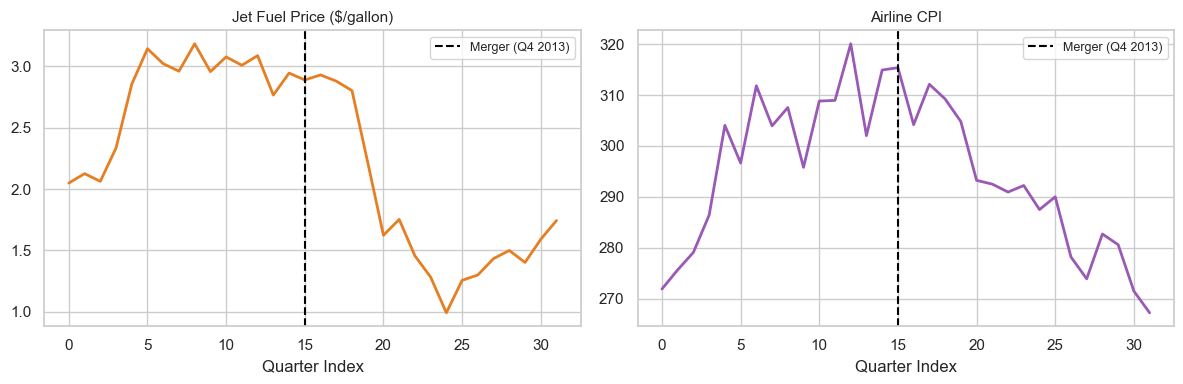

In [11]:
# Quick visual check: fuel and CPI coverage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

jet_plot = jet_q[(jet_q['Year'] >= 2010) & (jet_q['Year'] <= 2017)].copy()
jet_plot['qidx'] = (jet_plot['Year'] - 2010) * 4 + (jet_plot['Quarter'] - 1)

cpi_plot = cpi_q[(cpi_q['Year'] >= 2010) & (cpi_q['Year'] <= 2017)].copy()
cpi_plot['qidx'] = (cpi_plot['Year'] - 2010) * 4 + (cpi_plot['Quarter'] - 1)

axes[0].plot(jet_plot['qidx'], jet_plot['jet_fuel_price'], color='#e67e22', linewidth=2)
axes[0].axvline(15, color='black', linestyle='--', linewidth=1.5, label='Merger (Q4 2013)')
axes[0].set_title('Jet Fuel Price ($/gallon)', fontsize=11)
axes[0].set_xlabel('Quarter Index')
axes[0].legend(fontsize=9)

axes[1].plot(cpi_plot['qidx'], cpi_plot['airline_cpi'], color='#9b59b6', linewidth=2)
axes[1].axvline(15, color='black', linestyle='--', linewidth=1.5, label='Merger (Q4 2013)')
axes[1].set_title('Airline CPI', fontsize=11)
axes[1].set_xlabel('Quarter Index')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 7 — State Fixed Effect Encoding

Encode `OriginState` and `DestState` as integer codes for the Double ML model. Using `LabelEncoder` (not `get_dummies`) to avoid adding ~100 dummy columns.

The fitted encoders are saved to `models/artifacts/` so the Flask API can decode predictions and encode user-supplied routes at inference time.

In [12]:
from sklearn.preprocessing import LabelEncoder

# Fill any missing state codes before encoding
panel['OriginState'] = panel['OriginState'].fillna('UNK')
panel['DestState']   = panel['DestState'].fillna('UNK')

le_origin = LabelEncoder()
le_dest   = LabelEncoder()

panel['origin_state_code'] = le_origin.fit_transform(panel['OriginState'])
panel['dest_state_code']   = le_dest.fit_transform(panel['DestState'])

print(f'Origin state codes: {len(le_origin.classes_)} distinct values  {list(le_origin.classes_[:6])}...')
print(f'Dest   state codes: {len(le_dest.classes_)} distinct values  {list(le_dest.classes_[:6])}...')

# Save encoders for API use
joblib.dump(le_origin, MODELS_DIR / 'le_origin_state.pkl')
joblib.dump(le_dest,   MODELS_DIR / 'le_dest_state.pkl')
print('Saved le_origin_state.pkl and le_dest_state.pkl')

Origin state codes: 51 distinct values  ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO']...
Dest   state codes: 51 distinct values  ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO']...
Saved le_origin_state.pkl and le_dest_state.pkl


---
## Section 8 — Panel Validation

Run sanity checks before saving. All checks should pass. Flag anything unexpected before proceeding to modeling.

In [13]:
# Define key modeling columns that must have no missing values
key_cols = [
    'avg_fare', 'log_avg_fare', 'treated', 'post', 'treated_post',
    'quarter_idx', 'event_time', 'hhi', 'n_carriers',
    'avg_distance', 'jet_fuel_price', 'log_jet_fuel', 'airline_cpi',
    'total_passengers', 'origin_state_code', 'dest_state_code'
]

print('=' * 55)
print('PANEL VALIDATION')
print('=' * 55)

# 1. Shape
print(f'\n[1] Shape')
print(f'    Panel shape   : {panel.shape}')
print(f'    Expected      : ~150,000-180,000 rows, ~25 columns')

# 2. Missing values in key columns
print(f'\n[2] Missing values in key modeling columns')
missing = panel[key_cols].isnull().sum()
missing_nonzero = missing[missing > 0]
if len(missing_nonzero) == 0:
    print('    None -- all key columns complete')
else:
    print(missing_nonzero.to_string())

# 3. Treatment counts
n_treated_routes = panel[panel['treated'] == 1]['route'].nunique()
n_control_routes = panel[panel['treated'] == 0]['route'].nunique()
print(f'\n[3] Route counts')
print(f'    Treated routes : {n_treated_routes:,}')
print(f'    Control routes : {n_control_routes:,}')
print(f'    Treatment share: {n_treated_routes/(n_treated_routes+n_control_routes):.1%}')

# 4. Pre/post split
print(f'\n[4] Pre / post split')
print(f'    Pre-merger rows  : {(panel["post"] == 0).sum():,}')
print(f'    Post-merger rows : {(panel["post"] == 1).sum():,}')

# 5. Fare sanity
print(f'\n[5] Fare sanity check')
print(f'    Overall avg fare : ${panel["avg_fare"].mean():.2f}')
print(f'    Treated avg fare : ${panel[panel["treated"]==1]["avg_fare"].mean():.2f}')
print(f'    Control avg fare : ${panel[panel["treated"]==0]["avg_fare"].mean():.2f}')
print(f'    Fare range       : ${panel["avg_fare"].min():.2f} -- ${panel["avg_fare"].max():.2f}')

# 6. HHI sanity
print(f'\n[6] HHI sanity check')
print(f'    HHI range            : {panel["hhi"].min():.3f} -- {panel["hhi"].max():.3f}')
print(f'    HHI mean treated pre : {panel[(panel["treated"]==1)&(panel["post"]==0)]["hhi"].mean():.3f}')
print(f'    HHI mean treated post: {panel[(panel["treated"]==1)&(panel["post"]==1)]["hhi"].mean():.3f}')
print(f'    (HHI should increase post-merger on treated routes)')

# 7. Quarter coverage
print(f'\n[7] Quarter coverage')
print(f'    quarter_idx range : {panel["quarter_idx"].min()} to {panel["quarter_idx"].max()}')
print(f'    event_time range  : {panel["event_time"].min()} to {panel["event_time"].max()}')
n_qtr = panel['quarter_idx'].nunique()
print(f'    Distinct quarters : {n_qtr}  (expected 32)')

print(f'\n{"=" * 55}')

PANEL VALIDATION

[1] Shape
    Panel shape   : (122787, 25)
    Expected      : ~150,000-180,000 rows, ~25 columns

[2] Missing values in key modeling columns
    None -- all key columns complete

[3] Route counts
    Treated routes : 1,223
    Control routes : 3,721
    Treatment share: 24.7%

[4] Pre / post split
    Pre-merger rows  : 59,481
    Post-merger rows : 63,306

[5] Fare sanity check
    Overall avg fare : $246.29
    Treated avg fare : $262.59
    Control avg fare : $239.10
    Fare range       : $20.20 -- $1738.45

[6] HHI sanity check
    HHI range            : 0.122 -- 1.000
    HHI mean treated pre : 0.652
    HHI mean treated post: 0.634
    (HHI should increase post-merger on treated routes)

[7] Quarter coverage
    quarter_idx range : 0 to 31
    event_time range  : -15 to 16
    Distinct quarters : 32  (expected 32)



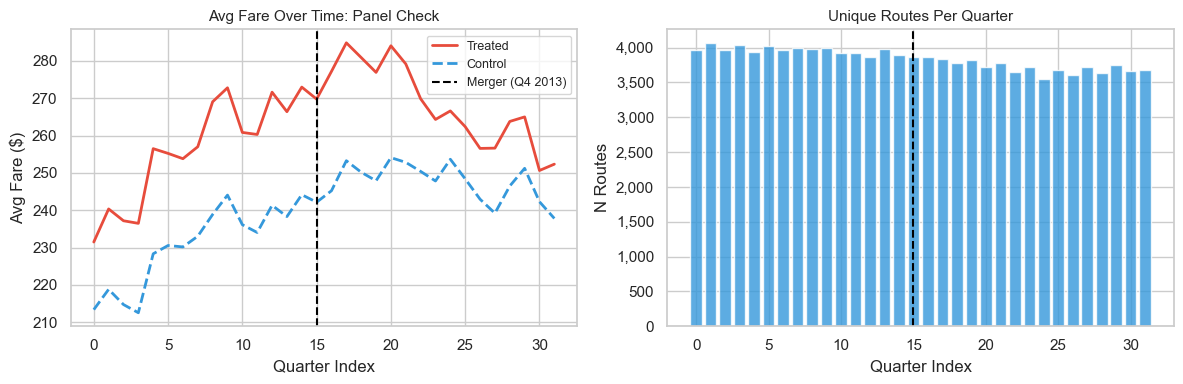

In [14]:
# Validation plots: fare trends and route coverage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: avg fare over time by treatment group
ts = (
    panel.groupby(['quarter_idx', 'treated'])['avg_fare']
    .mean().reset_index()
)
for treated_val, color, label, ls in [
    (1, '#e74c3c', 'Treated', '-'),
    (0, '#3498db', 'Control', '--')
]:
    sub = ts[ts['treated'] == treated_val].sort_values('quarter_idx')
    axes[0].plot(sub['quarter_idx'], sub['avg_fare'],
                 color=color, linestyle=ls, linewidth=2, label=label)
axes[0].axvline(15, color='black', linestyle='--', linewidth=1.5, label='Merger (Q4 2013)')
axes[0].set_title('Avg Fare Over Time: Panel Check', fontsize=11)
axes[0].set_xlabel('Quarter Index')
axes[0].set_ylabel('Avg Fare ($)')
axes[0].legend(fontsize=9)

# Right: route count per quarter (should be stable)
route_ct = panel.groupby('quarter_idx')['route'].nunique()
axes[1].bar(route_ct.index, route_ct.values, color='#3498db', alpha=0.8)
axes[1].axvline(15, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Unique Routes Per Quarter', fontsize=11)
axes[1].set_xlabel('Quarter Index')
axes[1].set_ylabel('N Routes')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

plt.tight_layout()
plt.show()

In [15]:
# Final column list and dtypes for modeling notebook reference
print('Final panel columns and dtypes:')
print(panel.dtypes.to_string())
print(f'\nTotal memory usage: {panel.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Final panel columns and dtypes:
Year                   int64
Quarter                int64
route                    str
treated                int64
post                   int64
treated_post           int64
quarter_idx            int64
event_time             int64
Origin                   str
Dest                     str
OriginState              str
DestState                str
avg_fare             float64
median_fare          float64
log_avg_fare         float64
total_passengers     float64
n_tickets              int64
avg_distance         float64
n_carriers             int64
hhi                  float64
jet_fuel_price       float64
airline_cpi          float64
log_jet_fuel         float64
origin_state_code      int64
dest_state_code        int64

Total memory usage: 26.7 MB


---
## Section 9 — Save Output

Save `panel.parquet` (the modeling dataset) and a data dictionary CSV documenting every column.

In [16]:
# Save panel
panel.to_parquet(PROC_DIR / 'panel.parquet', index=False)
saved_size = (PROC_DIR / 'panel.parquet').stat().st_size / 1e6
print(f'Saved panel.parquet -- {panel.shape[0]:,} rows, {panel.shape[1]} columns, {saved_size:.1f} MB')

Saved panel.parquet -- 122,787 rows, 25 columns, 4.8 MB


In [17]:
# Save data dictionary
col_descriptions = {
    'Year':              'Calendar year',
    'Quarter':           'Calendar quarter (1-4)',
    'route':             'Origin-Dest airport code pair e.g. LAX-PHL',
    'Origin':            'Origin airport code (3-letter IATA)',
    'Dest':              'Destination airport code (3-letter IATA)',
    'OriginState':       'Origin state abbreviation',
    'DestState':         'Destination state abbreviation',
    'origin_state_code': 'Label-encoded origin state (integer, fitted on full panel)',
    'dest_state_code':   'Label-encoded destination state (integer, fitted on full panel)',
    'treated':           '1 if both AA and US flew this route pre-merger, else 0',
    'post':              '1 if quarter is Q4 2013 or later, else 0',
    'treated_post':      'DiD interaction term: treated x post',
    'quarter_idx':       'Integer time index: 0=2010Q1, 15=2013Q4 (merger), 31=2017Q4',
    'event_time':        'Quarters relative to merger: 0=merger quarter, negative=pre',
    'avg_fare':          'Mean MktFare across all tickets on this route-quarter ($)',
    'median_fare':       'Median MktFare on this route-quarter ($)',
    'log_avg_fare':      'Mean of log(MktFare) -- primary outcome for log-linear models',
    'total_passengers':  'Sum of Passengers x 10 (population-level estimate)',
    'n_tickets':         'Number of ticket observations in DB1B 10% sample',
    'avg_distance':      'Mean MktDistance in miles for this route-quarter',
    'n_carriers':        'Number of distinct operating carriers on this route-quarter',
    'hhi':               'Herfindahl-Hirschman Index (0=competitive, 1=monopoly)',
    'jet_fuel_price':    'Quarterly avg jet fuel price ($/gallon, US Gulf Coast WJFUELUSGULF)',
    'log_jet_fuel':      'log(jet_fuel_price)',
    'airline_cpi':       'Quarterly avg airline CPI (BLS CUSR0000SETG01)',
}

pd.DataFrame({
    'column':      list(col_descriptions.keys()),
    'description': list(col_descriptions.values())
}).to_csv(PROC_DIR / 'panel_data_dictionary.csv', index=False)
print('Saved panel_data_dictionary.csv')

Saved panel_data_dictionary.csv


In [18]:
# Reload verification — confirm parquet round-trips correctly
panel_check = pd.read_parquet(PROC_DIR / 'panel.parquet')
assert panel_check.shape == panel.shape, f'Shape mismatch: {panel_check.shape} vs {panel.shape}'
assert list(panel_check.columns) == list(panel.columns), 'Column mismatch after reload'
print(f'Reload verification passed -- {panel_check.shape[0]:,} rows, {panel_check.shape[1]} columns')
del panel_check

Reload verification passed -- 122,787 rows, 25 columns


---
## Summary

The preprocessing pipeline produced `data/processed/panel.parquet` with:

| Item | Value |
|---|---|
| Unit of observation | Route × Quarter |
| Study period | 2010 Q1 – 2017 Q4 (32 quarters) |
| Filters applied | Domestic nonstop, no bulk fares, MktFare $20–$2000 |
| Outcome variable | `log_avg_fare` (log-linear specification) |
| Treatment variable | `treated_post` (DiD interaction) |
| Key controls | `hhi`, `n_carriers`, `avg_distance`, `log_jet_fuel`, `airline_cpi`, state codes |
| Also saved | `treatment_assignment.parquet`, `panel_data_dictionary.csv`, state LabelEncoders |

**Next:** `03_modeling.ipynb` — Pooled OLS, Two-Way Fixed Effects, Double ML, Causal Forest, SHAP, but-for price construction, and damages estimation.